In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adilshamim8/predict-calorie-expenditure",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipython-input-478/2007941106.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'predict-calorie-expenditure' dataset.
First 5 records:    id     Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0   0    male   36   189.0    82.0      26.0       101.0       41.0     150.0
1   1  female   64   163.0    60.0       8.0        85.0       39.7      34.0
2   2  female   51   161.0    64.0       7.0        84.0       39.8      29.0
3   3    male   20   192.0    90.0      25.0       105.0       40.7     140.0
4   4  female   38   166.0    61.0      25.0       102.0       40.6     146.0


#Libraries

In [ ]:
# Basic system and data handling
import os
import pandas as pd
import numpy as np
from pprint import pprint

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities (for data preparation)
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor


# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_context("notebook")

In [ ]:
df_subset = df.sample(n=100000, random_state=42)
df=df_subset

#Data Preprocessing

In [ ]:
# Drop the 'id' column as it has no predictive power
df=df.drop(columns=['id'])

In [ ]:

df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
404846,female,56,163.0,61.0,29.0,108.0,40.8,200.0
580313,male,44,179.0,87.0,13.0,94.0,40.3,64.0
552086,male,41,186.0,84.0,10.0,89.0,39.9,39.0
370876,female,38,161.0,58.0,19.0,98.0,40.6,103.0
239330,male,57,181.0,77.0,9.0,98.0,40.0,52.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 404846 to 746185
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         100000 non-null  object 
 1   Age         100000 non-null  int64  
 2   Height      100000 non-null  float64
 3   Weight      100000 non-null  float64
 4   Duration    100000 non-null  float64
 5   Heart_Rate  100000 non-null  float64
 6   Body_Temp   100000 non-null  float64
 7   Calories    100000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 6.9+ MB


#check missing values and duplicates

In [ ]:
print('Data set shape:',df.shape)
#column names
df.columns
df.info()
df.describe()

#Check missing values
df.isnull().sum()

Data set shape: (100000, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 404846 to 746185
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         100000 non-null  object 
 1   Age         100000 non-null  int64  
 2   Height      100000 non-null  float64
 3   Weight      100000 non-null  float64
 4   Duration    100000 non-null  float64
 5   Heart_Rate  100000 non-null  float64
 6   Body_Temp   100000 non-null  float64
 7   Calories    100000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 6.9+ MB


,0
Sex,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [ ]:
# Total duplicate rows
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 43


In [ ]:
df = df.drop_duplicates()
print('Duplicates were removed')
df.shape

Duplicates were removed


(99957, 8)

#Feature Engineering

In [ ]:
num_cols = ['Age','Height','Weight','Heart_Rate','Body_Temp','Calories','Duration']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Height: 3 outliers
Weight: 1 outliers
Heart_Rate: 3 outliers
Body_Temp: 1962 outliers
Calories: 18 outliers
Duration: 0 outliers


## Outliers removed dataset

In [ ]:
import numpy as np

num_cols = ['Age','Height','Weight','Heart_Rate','Body_Temp','Calories','Duration']

df_clean = df.copy()

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (99957, 8)
After removing outliers: (97969, 8)


####This cleaned dataset will use later on to choose best model

#Split Dataset

In [ ]:
# Features (all variables except target)
X = df.drop(columns=['Calories'])

# Target variable
y = df['Calories']

# Identify columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,      # 30% test data
    random_state=42,     # for reproducibility
    shuffle=True         # shuffle data before splitting
)

Categorical: ['Sex']
Numerical: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


In [ ]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("Training target size:", y_train.shape)
print("Testing target size:", y_test.shape)

Training set size: (69969, 7)
Testing set size: (29988, 7)
Training target size: (69969,)
Testing target size: (29988,)


In [ ]:
# Combine X_train and y_train into one DataFrame
train_df = pd.concat(
    [pd.DataFrame(X_train), pd.Series(y_train, name="target")],
    axis=1
)

# Save as CSV
train_df.to_csv("training_dataset.csv", index=False)

print("Training dataset saved as training_dataset.csv")

Training dataset saved as training_dataset.csv


In [ ]:
train_df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,target
138094,female,50,164.0,64.0,26.0,108.0,40.8,173.0
599097,male,44,182.0,84.0,11.0,90.0,40.1,48.0
195238,male,65,176.0,72.0,5.0,82.0,38.7,19.0
414798,female,44,168.0,71.0,27.0,102.0,41.0,158.0
440945,male,55,192.0,94.0,20.0,98.0,40.7,129.0


##Define Evaluating Functions

# Define Evaluation functions

In [ ]:
def evaluate_model(y_true, y_pred):
    """
    Calculates and prints common regression evaluation metrics.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R2): {r2:.4f}")
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

In [ ]:
def cross_validate_model(model, X, y, cv):
    """
    Performs cross-validation using cross_val_predict
    and returns standard regression metrics.
    """
    model_cv = clone(model)

    y_cv_pred = cross_val_predict(model_cv, X, y, cv=cv)

    metrics = {
        "R2": r2_score(y, y_cv_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_cv_pred)),
        "MAE": mean_absolute_error(y, y_cv_pred),
        "MAPE": mean_absolute_percentage_error(y, y_cv_pred)
    }

    return metrics

## Create single function for model evaluation

In [ ]:
def evaluate_model_full(model, X_train, y_train, X_test, y_test, cv):
    """
    Trains a model and returns Train, CV, and Test metrics
    in a single structured dictionary.
    """
    model_ = clone(model)

    # Fit on training data
    model_.fit(X_train, y_train)

    # --- Train metrics ---
    y_train_pred = model_.predict(X_train)
    train_metrics = {
        "R2": r2_score(y_train, y_train_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "MAE": mean_absolute_error(y_train, y_train_pred)
    }

    # --- Cross-validation metrics ---
    y_cv_pred = cross_val_predict(clone(model), X_train, y_train, cv=cv)
    cv_metrics = {
        "R2": r2_score(y_train, y_cv_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_cv_pred)),
        "MAE": mean_absolute_error(y_train, y_cv_pred)
    }

    # --- Test metrics ---
    y_test_pred = model_.predict(X_test)
    test_metrics = {
        "R2": r2_score(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "MAE": mean_absolute_error(y_test, y_test_pred)
    }

    return {
        "train": train_metrics,
        "cv": cv_metrics,
        "test": test_metrics,
        "fitted_model": model_
    }

#Modeling

# Task
Define baseline regression models including Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Train each model using a pipeline that includes data preprocessing (scaling numerical features and one-hot encoding categorical features) and evaluate their performance on the training, cross-validation, and test sets using R2, RMSE, and MAE metrics. Finally, display a summary of these evaluation metrics for all baseline models.

## Define Baseline Models

### Subtask:
Create a dictionary of common regression models to be used as baselines, such as Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor.


**Reasoning**:
I need to instantiate the specified regression models and store them in a dictionary named `baseline_models` for subsequent use. I'll use ExtraTreesRegressor instead of DecisionTreeRegressor as it's already imported in the notebook.



**Reasoning**:
Now that the baseline models are defined, I will iterate through them, create a preprocessing pipeline for each, train them, evaluate their performance using the predefined `evaluate_model_full` function on training, cross-validation, and test sets, and store the metrics in a dictionary. Finally, I will display a summary of these metrics.



In [ ]:
from sklearn.pipeline import Pipeline

CV_FOLDS = 5
results = {}

In [ ]:
import pandas as pd

def make_results_table(metrics):
    return pd.DataFrame({
        "Dataset": ["Train", "CV", "Test"],
        "R2": [
            metrics["train"]["R2"],
            metrics["cv"]["R2"],
            metrics["test"]["R2"]
        ],
        "RMSE": [
            metrics["train"]["RMSE"],
            metrics["cv"]["RMSE"],
            metrics["test"]["RMSE"]
        ]
    }).assign()[["Dataset", "R2", "RMSE"]]

# Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

name = "Linear Regression"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Evaluate
metrics = evaluate_model_full(
    pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

# Store
results = metrics

# Results table
lr_table = make_results_table(metrics)
display(lr_table)

# ---- Equation ----
pipeline.fit(X_train, y_train)

lr = pipeline.named_steps["regressor"]
features = pipeline.named_steps["preprocessor"].get_feature_names_out()

print("\nRegression Equation:")
print(f"y = {lr.intercept_:.4f}", end=" ")
for f, c in zip(features, lr.coef_):
    print(f"{c:+.4f}·{f}", end=" ")

,Dataset,R2,RMSE
0,Train,0.968369,11.071555
1,CV,0.968359,11.073367
2,Test,0.968338,11.119766



Regression Equation:
y = 88.1364 +8.0332·num__Age -1.7530·num__Height +3.7137·num__Weight +56.4812·num__Duration +18.2137·num__Heart_Rate -14.1072·num__Body_Temp +0.8833·cat__Sex_female -0.8833·cat__Sex_male 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_train)

# Residuals
residuals = y_train - y_pred

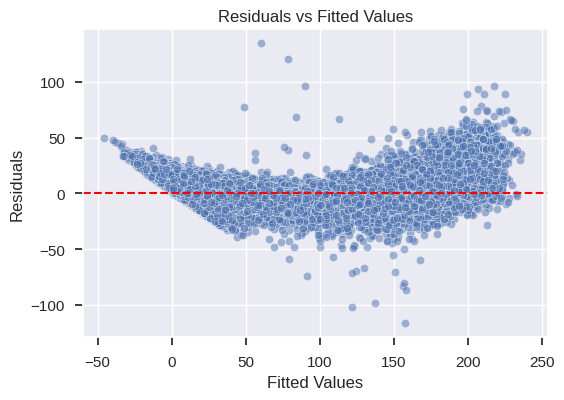

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

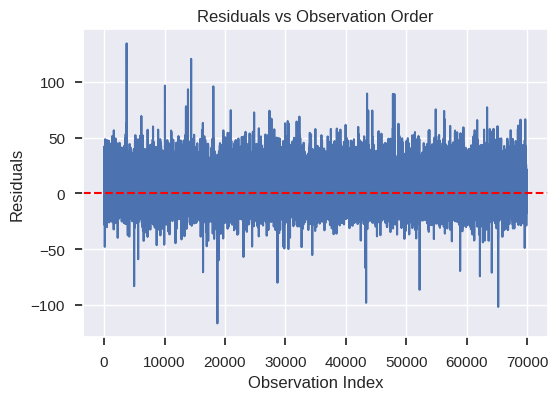

Durbin-Watson Statistic: 1.999


In [ ]:
# Residuals vs order
plt.figure(figsize=(6,4))
plt.plot(residuals.values)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Observation Index")
plt.ylabel("Residuals")
plt.title("Residuals vs Observation Order")
plt.show()

# Durbin-Watson test
dw_stat = durbin_watson(residuals)
print("Durbin-Watson Statistic:", round(dw_stat, 3))

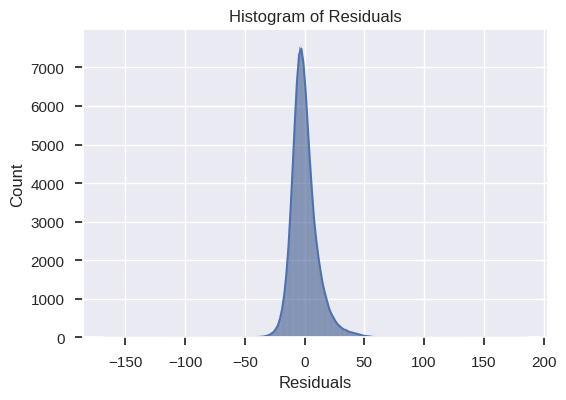

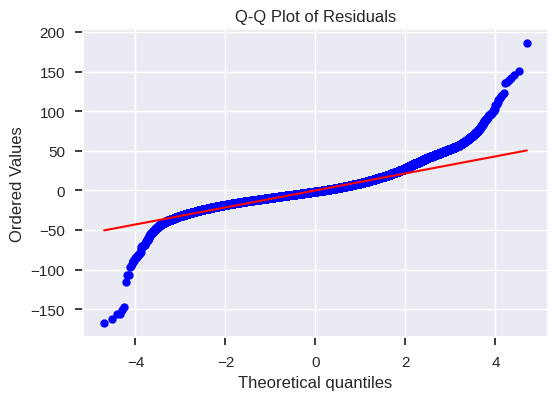

In [ ]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.show()

# Q-Q plot
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

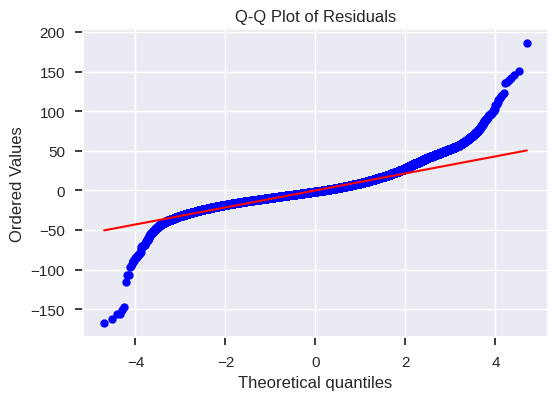

In [ ]:
# Q-Q plot
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

#Ridge regression

In [ ]:
from sklearn.linear_model import Ridge

name = "Ridge Regression"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

metrics = evaluate_model_full(
    pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

results = metrics

ridge_table = make_results_table(metrics)
display(ridge_table)

,Dataset,R2,RMSE
0,Train,0.968369,11.071556
1,CV,0.968359,11.073368
2,Test,0.968338,11.119749


# Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

name = "Lasso Regression"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso())
])

metrics = evaluate_model_full(
    pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

results = metrics

lasso_table = make_results_table( metrics)
display(lasso_table)

,Dataset,R2,RMSE
0,Train,0.962322,12.083682
1,CV,0.962309,12.085709
2,Test,0.962312,12.131776


# Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline

name = "Elastic Net Regression"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ElasticNet()
    )
])

metrics = evaluate_model_full(
    pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

results = metrics

elastic_net_table = make_results_table(metrics)
display(elastic_net_table)

,Dataset,R2,RMSE
0,Train,0.902509,19.437379
1,CV,0.902498,19.438478
2,Test,0.902834,19.479674


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

name = "Random Forest"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor()

    )
])

metrics = evaluate_model_full(
    pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

results= metrics

rf_table = make_results_table(metrics)
display(rf_table)

,Dataset,R2,RMSE
0,Train,0.999401,1.524206
1,CV,0.995673,4.094832
2,Test,0.995745,4.076481


# XG Boost

In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

name = "XGBoost Regression"

XGB_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor()
    )
])

# Evaluate
metrics = evaluate_model_full(
    XGB_pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

results[name] = metrics

# Results table
xgb_table = make_results_table(metrics)
display(xgb_table)

# Refit FINAL model (important for saving)
XGB_pipeline.fit(X_train, y_train)

,Dataset,R2,RMSE
0,Train,0.997292,3.239677
1,CV,0.995757,4.055178
2,Test,0.995971,3.966599


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'Duration', 'Heart_Rate',
                                                   'Body_Temp']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

# Save Model to pickle file

In [ ]:
import pickle

filename = "xgb_model.pkl"

with open(filename, "wb") as file:
    pickle.dump(XGB_pipeline, file)

print(f"XGBoost model successfully saved to {filename}")

XGBoost model successfully saved to xgb_model.pkl


In [ ]:
with open('xgb_model.pkl','rb') as f:
  mp=pickle.load(f)


In [ ]:
# Take a sample from the test set for prediction
sample_input = X_test.head(5)

# Make predictions using the loaded model 'mp'
predictions = mp.predict(sample_input)

print("Sample Input (first 5 rows from X_test):")
print(sample_input)
print("\nPredictions:")
print(predictions)

Sample Input (first 5 rows from X_test):
           Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
666622    male   52   191.0   103.0      14.0        96.0       40.3
363176    male   51   189.0    91.0      23.0        99.0       40.5
82049   female   31   169.0    64.0      23.0       100.0       41.1
257007    male   26   179.0    81.0      11.0        97.0       39.6
634598    male   42   190.0    93.0      16.0        95.0       40.2

Predictions:
[ 85.29857  140.69513  124.746605  47.668385  83.00028 ]


#Hyperparameter Tuning

## Ridge

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import numpy as np

name = "Ridge Regression (Tuned)"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid = {
    "regressor__alpha": np.logspace(-3, 3, 20)
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
best_alpha = grid.best_params_["regressor__alpha"]

In [ ]:
metrics = evaluate_model_full(
    best_pipeline,
    X_train, y_train,
    X_test, y_test,
    CV_FOLDS
)

ridge_tuned_table = make_results_table(metrics)
display(ridge_tuned_table)

print("Best alpha:", best_alpha)

,Dataset,R2,RMSE
0,Train,0.968369,11.071555
1,CV,0.968359,11.073367
2,Test,0.968338,11.119766


Best alpha: 0.001


##Lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

name = "Lasso Regression (Tuned)"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(max_iter=5000))
])

param_grid = {
    "regressor__alpha": np.logspace(-4, 1, 20)
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
best_alpha = grid.best_params_["regressor__alpha"]

In [ ]:
metrics = evaluate_model_full(
    best_pipeline,
    X_train, y_train,
    X_test, y_test,
    CV_FOLDS
)

lasso_tuned_table = make_results_table(metrics)
display(lasso_tuned_table)

print("Best alpha:", best_alpha)

,Dataset,R2,RMSE
0,Train,0.968369,11.071556
1,CV,0.968359,11.073368
2,Test,0.968338,11.119767


Best alpha: 0.0001


#Elastic net

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

name = "Elastic Net Regression (Randomized Tuned)"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", ElasticNet(max_iter=5000))
])

param_dist = {
    "regressor__alpha": np.logspace(-4, 1, 100),   # continuous-like
    "regressor__l1_ratio": np.linspace(0.05, 0.95, 20)
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,                      # 🔥 fast
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
best_params = random_search.best_params_

print("Best Elastic Net parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")

Best Elastic Net parameters:
regressor__l1_ratio: 0.5236842105263158
regressor__alpha: 0.00020092330025650479


In [ ]:
metrics = evaluate_model_full(
    best_pipeline,
    X_train, y_train,
    X_test, y_test,
    CV_FOLDS
)

elastic_net_random_table = make_results_table(metrics)
display(elastic_net_random_table)

,Dataset,R2,RMSE
0,Train,0.968369,11.071569
1,CV,0.968359,11.073382
2,Test,0.968338,11.119663


# Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

name = "Random Forest (FAST Tuned)"

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# FAST parameter space (high impact only)
param_dist = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2],
    "regressor__max_features": ["sqrt", 0.5]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,           # 🔥 reduced
    cv=3,                # 🔥 fewer folds
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
best_params = random_search.best_params_

print("Best parameters from FAST RF tuning:")
for k, v in best_params.items():
    print(f"{k}: {v}")

Best parameters from FAST RF tuning:
regressor__n_estimators: 300
regressor__min_samples_split: 2
regressor__min_samples_leaf: 1
regressor__max_features: 0.5
regressor__max_depth: 20


In [ ]:
metrics = evaluate_model_full(
    best_pipeline,
    X_train, y_train,
    X_test, y_test,
    CV_FOLDS
)

rf_fast_table = make_results_table(metrics)
display(rf_fast_table)

,Dataset,R2,RMSE
0,Train,0.999439,1.474133
1,CV,0.995955,3.959189
2,Test,0.996143,3.881005


XG Boost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

name = "XGBoost Regression (FAST Tuned)"

# FAST pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",        # 🔥 very important
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

# FAST hyperparameter space (high impact only)
param_dist = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [3, 4, 5],
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,                   # 🔥 small but effective
    cv=3,                        # 🔥 faster CV
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
best_params = random_search.best_params_

print("Best parameters from FAST tuning:")
for k, v in best_params.items():
    print(f"{k}: {v}")

Best parameters from FAST tuning:
regressor__subsample: 0.8
regressor__n_estimators: 300
regressor__max_depth: 5
regressor__learning_rate: 0.1
regressor__colsample_bytree: 0.8


In [ ]:
metrics = evaluate_model_full(
    best_pipeline,
    X_train, y_train,
    X_test, y_test,
    CV_FOLDS
)

xgb_fast_table = make_results_table(metrics)
display(xgb_fast_table)

,Dataset,R2,RMSE
0,Train,0.997166,3.314278
1,CV,0.996239,3.817687
2,Test,0.996396,3.751651


#Without outliers

[Click this link to access Analysis without Outliers ](https://colab.research.google.com/drive/1_q9CjfhqeB9HL2fRUqOEw7c4_XVCtjb1?usp=sharing)

#Feature Importance plot

In [ ]:
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
print("Feature names after preprocessing:")
print(feature_names)

Feature names after preprocessing:
['num__Age' 'num__Height' 'num__Weight' 'num__Duration' 'num__Heart_Rate'
 'num__Body_Temp' 'cat__Sex_female' 'cat__Sex_male']


In [ ]:
import pandas as pd

# Get feature importances from the best XGBoost model
importance_scores = best_pipeline.named_steps['regressor'].feature_importances_

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

Feature Importances:
           Feature  Importance
3    num__Duration    0.796812
4  num__Heart_Rate    0.103699
5   num__Body_Temp    0.052707
0         num__Age    0.018749
6  cat__Sex_female    0.014907
7    cat__Sex_male    0.008677
2      num__Weight    0.003894
1      num__Height    0.000556


/tmp/ipython-input-743/475125940.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


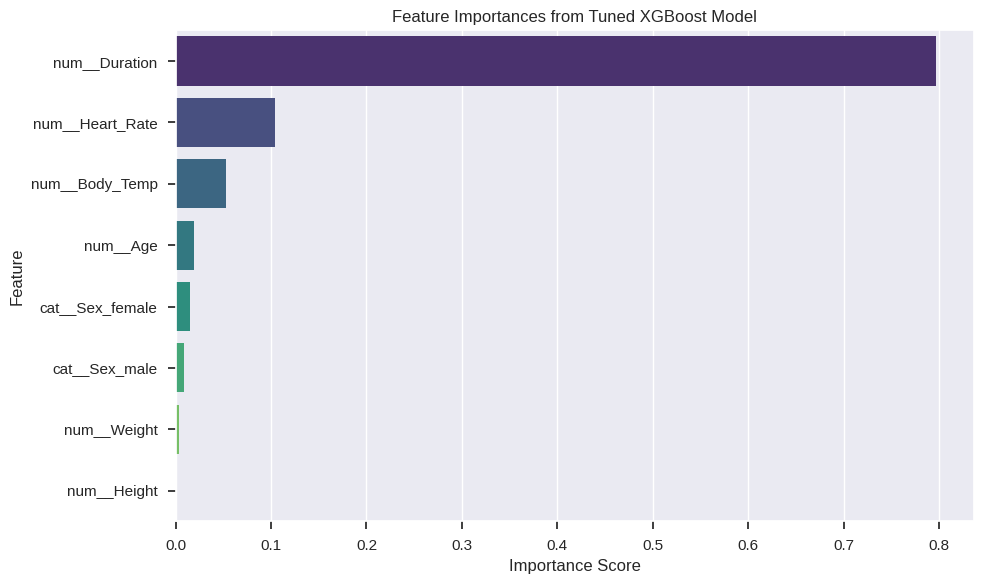

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger figure size for better readability
plt.figure(figsize=(10, 6))

# Create the horizontal bar plot
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Add title and labels
plt.title('Feature Importances from Tuned XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Display the plot
plt.tight_layout()
plt.show()

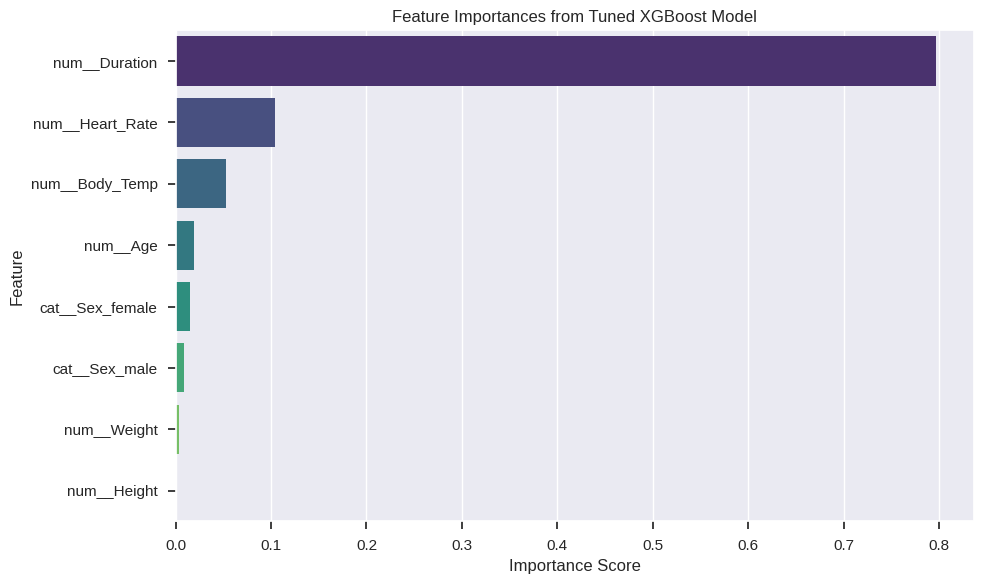

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger figure size for better readability
plt.figure(figsize=(10, 6))

# Create the horizontal bar plot, addressing the FutureWarning
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False)

# Add title and labels
plt.title('Feature Importances from Tuned XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Display the plot
plt.tight_layout()
plt.show()

# Partial Dependency Plots

In [ ]:
pdp_features_original = ['Duration', 'Heart_Rate', 'Body_Temp', 'Age', 'Sex', 'Weight', 'Height']
numerical_pdp_features = [feature for feature in pdp_features_original if feature in numerical_cols]

print("Numerical features selected for PDP:", numerical_pdp_features)

Numerical features selected for PDP: ['Duration', 'Heart_Rate', 'Body_Temp', 'Age', 'Weight', 'Height']


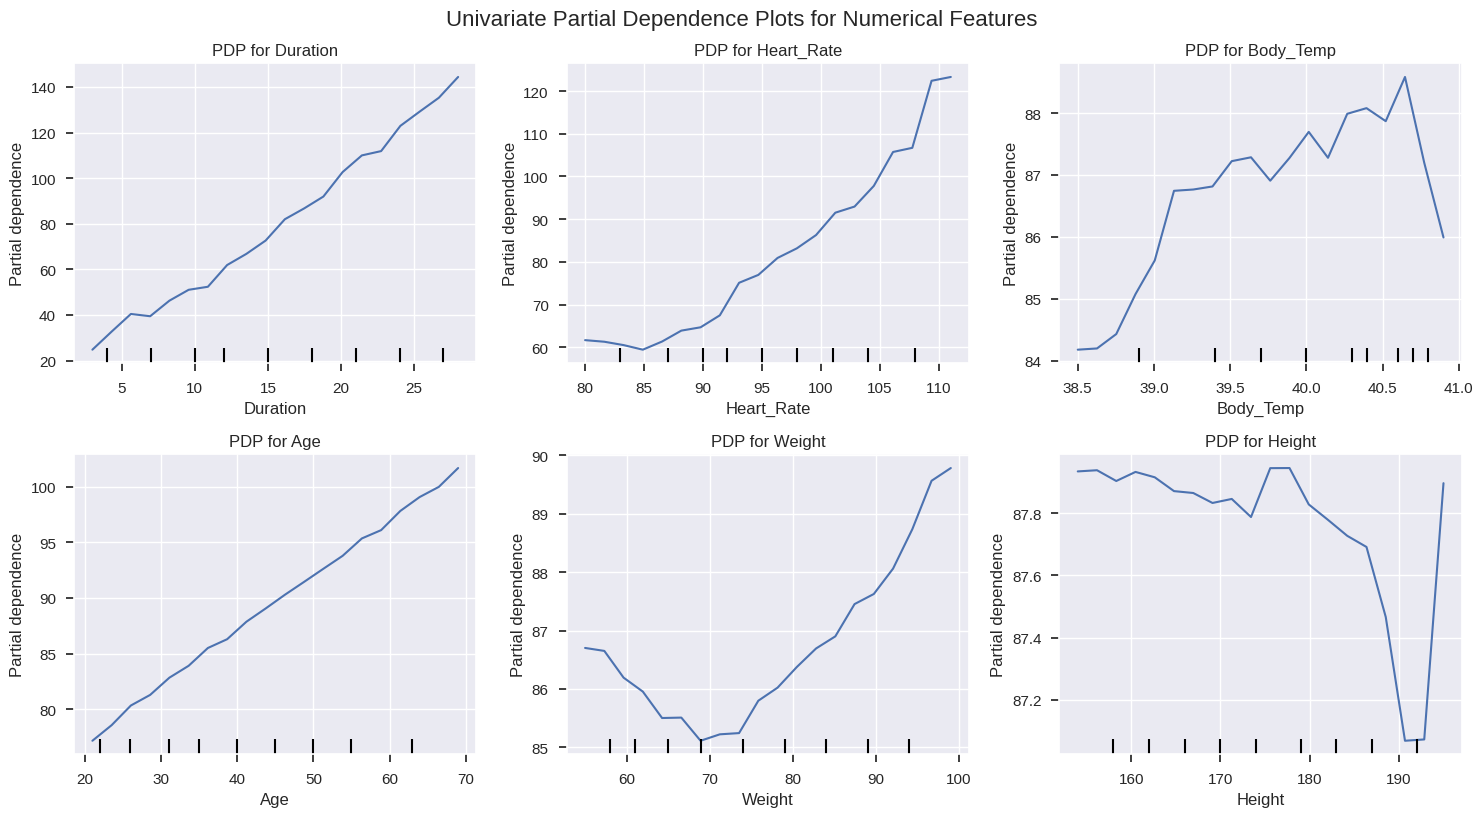

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# The numerical_pdp_features list already contains the original column names
# that are present in X_train. No need for 'num__' prefix here for the 'features' argument.
# processed_numerical_pdp_features = ['num__' + feature for feature in numerical_pdp_features if feature in numerical_cols]

# Determine grid size for subplots
num_plots = len(numerical_pdp_features)
nrows = (num_plots + 2) // 3 # Roughly 3 columns, adjust rows as needed
cols = min(num_plots, 3)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten() # Flatten for easy iteration

for i, feature in enumerate(numerical_pdp_features):
    ax = axes[i]
    PartialDependenceDisplay.from_estimator(
        estimator=best_pipeline,
        X=X_train, # X_train contains original column names
        features=[feature], # Use original feature name as it's in X_train
        # feature_names=feature_names, # This argument is ignored when X is a DataFrame and can cause confusion or errors
        kind='average', # Changed from 'individual' to 'average' to show single line
        grid_resolution=20,
        ax=ax
    )
    ax.set_title(f'PDP for {feature}') # Title should use original feature name

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Univariate Partial Dependence Plots for Numerical Features', y=1.02, fontsize=16)
plt.show()

#Refit Model with most important features only

In [ ]:
important_numerical_cols = ['Duration', 'Heart_Rate', 'Body_Temp', 'Age', 'Weight']
important_categorical_cols = ['Sex']

print("Important Numerical Columns:", important_numerical_cols)
print("Important Categorical Columns:", important_categorical_cols)

Important Numerical Columns: ['Duration', 'Heart_Rate', 'Body_Temp', 'Age', 'Weight']
Important Categorical Columns: ['Sex']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), important_numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), important_categorical_cols)
    ]
)

print("Reduced preprocessor created successfully.")

Reduced preprocessor created successfully.


In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

name_reduced = "XGBoost Regression (Reduced Features - Tuned)"

# Create a new pipeline with the reduced preprocessor and best hyperparameters
reduced_pipeline = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        **{
k.replace('regressor__', ''): v for k, v in best_params.items()
}
    ))
])

# Evaluate the model with reduced features
metrics_reduced = evaluate_model_full(
    reduced_pipeline, X_train, y_train, X_test, y_test, CV_FOLDS
)

# Store results (if needed, in a dictionary for comparison)
# results[name_reduced] = metrics_reduced

# Create and display the results table
xgb_reduced_table = make_results_table(metrics_reduced)
display(xgb_reduced_table)

print("XGBoost model refitted with reduced features and evaluated.")

,Dataset,R2,RMSE
0,Train,0.997097,3.354317
1,CV,0.996189,3.842872
2,Test,0.996401,3.748754


XGBoost model refitted with reduced features and evaluated.


In [ ]:
import pandas as pd

# Retrieve the performance tables (assuming they are already defined and populated in the notebook context)
# xgb_fast_table is for the full model
# xgb_reduced_table is for the reduced model

# Add a 'Model' column to each table for identification
xgb_fast_table['Model'] = 'Full Model'
xgb_reduced_table['Model'] = 'Reduced Model'

# Combine the tables into a single DataFrame for comparison
comparison_table = pd.concat([xgb_fast_table, xgb_reduced_table], ignore_index=True)

# Reorder columns for better readability, placing 'Model' first
comparison_table = comparison_table[['Model', 'Dataset', 'R2', 'RMSE']]

print("Comparison of Full vs. Reduced XGBoost Model Performance:")
display(comparison_table)

Comparison of Full vs. Reduced XGBoost Model Performance:


,Model,Dataset,R2,RMSE
0,Full Model,Train,0.997166,3.314278
1,Full Model,CV,0.996239,3.817687
2,Full Model,Test,0.996396,3.751651
3,Reduced Model,Train,0.997097,3.354317
4,Reduced Model,CV,0.996189,3.842872
5,Reduced Model,Test,0.996401,3.748754


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

name = "XGBoost Regression (FAST Tuned)"

# FAST pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",        # 🔥 very important
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

# FAST hyperparameter space (high impact only)
param_dist = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [3, 4, 5],
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,                   # 🔥 small but effective
    cv=3,                        # 🔥 faster CV
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_pipeline = random_search.best_estimator_
best_params = random_search.best_params_

print("Best parameters from FAST tuning:")
for k, v in best_params.items():
    print(f"{k}: {v}")

Best parameters from FAST tuning:
regressor__subsample: 0.8
regressor__n_estimators: 300
regressor__max_depth: 5
regressor__learning_rate: 0.1
regressor__colsample_bytree: 0.8


In [ ]:
print(best_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'Duration', 'Heart_Rate',
                                                   'Body_Temp']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                    

In [ ]:
import joblib

# File name
model_path = "xgb_fast_reduced_pipeline.pkl"

# Save the entire pipeline
joblib.dump(best_pipeline, model_path)

print(f"Model saved to {model_path}")

Model saved to xgb_fast_reduced_pipeline.pkl


In [ ]:
from xgboost import XGBRegressor

# Check regressor type
assert isinstance(
    best_pipeline.named_steps["regressor"],
    XGBRegressor
), "This is NOT an XGBoost model!"

print("Confirmed: regressor is XGBoost")

# Check model is fitted
assert hasattr(
    best_pipeline.named_steps["regressor"],
    "feature_importances_"
), "XGBoost model is NOT trained!"

print("Confirmed: XGBoost model is trained")


Confirmed: regressor is XGBoost
Confirmed: XGBoost model is trained


In [ ]:
import pickle

model_path = "xgb_fast_reduced_pipeline.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)

print(f"Model successfully saved to {model_path}")

Model successfully saved to xgb_fast_reduced_pipeline.pkl
